In [0]:
import numpy as np, pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import warnings; warnings.filterwarnings("ignore")

np.random.seed(42)

# Fresh pull (schema may have changed since last run)
pdf = spark.table("datathon.belmonte_hunters.alpha_dataset").toPandas()
pdf["datetime_utc"]   = pd.to_datetime(pdf["datetime_utc"])
pdf["datetime_local"] = pd.to_datetime(pdf["datetime_local"])
pdf["target_date"]    = pd.to_datetime(pdf["target_date"])

# Folds (same as before) — redefined here so this cell is self-contained
folds = [
    (pd.Timestamp("2025-04-01"), pd.Timestamp("2025-04-08"), pd.Timestamp("2025-05-27")),
    (pd.Timestamp("2025-05-20"), pd.Timestamp("2025-05-27"), pd.Timestamp("2025-07-15")),
    (pd.Timestamp("2025-07-08"), pd.Timestamp("2025-07-15"), pd.Timestamp("2025-09-02")),
    (pd.Timestamp("2025-08-26"), pd.Timestamp("2025-09-02"), pd.Timestamp("2025-10-21")),
    (pd.Timestamp("2025-10-14"), pd.Timestamp("2025-10-21"), pd.Timestamp("2025-12-03")),
]

# Diagnostics
print(f"rows={len(pdf):,}  communities={pdf['community_code'].nunique()}  "
      f"span {pdf['target_date'].min().date()} → {pdf['target_date'].max().date()}")
print("\nNaN rate (key cols):")
print(pdf[["alpha_lag_7d","n_clients_at_cutoff","D_mw","total_kw",
           "temperature_2m","is_holiday"]].isna().mean().round(3))
print("\nRows per community:")
print(pdf.groupby("community_code").size().sort_values())
print("\nNegative/zero total_kw:", int((pdf["total_kw"] <= 0).sum()))

rows=489,408  communities=18  span 2025-01-29 → 2025-11-30

NaN rate (key cols):
alpha_lag_7d           0.000
n_clients_at_cutoff    0.000
D_mw                   0.000
total_kw               0.000
temperature_2m         0.001
is_holiday             0.000
dtype: float64

Rows per community:
community_code
CE     5952
ML    17856
CN    25048
AR    29368
CL    29368
CB    29368
GA    29368
AS    29368
MD    29368
RI    29368
CM    29372
AN    29372
MC    29372
EX    29372
NC    29372
CT    29372
PV    29372
VC    29372
dtype: int64

Negative/zero total_kw: 32


In [0]:
import numpy as np, pandas as pd
TAU = 2*np.pi

d = pdf.dropna(subset=["alpha_lag_7d"]).copy()
d["datetime_utc"]   = pd.to_datetime(d["datetime_utc"])
d["datetime_local"] = pd.to_datetime(d["datetime_local"])
d["target_date"]    = pd.to_datetime(d["target_date"])

# --- Baseline + multiplicative (log-ratio) target ---
eps = 1.0
d["baseline_kw"] = (d["alpha_lag_7d"] * d["n_clients_at_cutoff"] * d["D_mw"]).clip(lower=eps)
d["total_pos"]   = d["total_kw"].clip(lower=eps)
d["y_log"]       = np.log(d["total_pos"]) - np.log(d["baseline_kw"])   # tight, symmetric, scale-free
d["baseline_log"] = np.log(d["baseline_kw"])
d["log_clients"]  = np.log(d["n_clients_at_cutoff"].clip(lower=1))
d["log_dmw"]      = np.log(d["D_mw"].clip(lower=1))

# --- Year-cycle Fourier harmonics (the seasonality your sin/cos_mod misses) ---
for k in (1,2,3,4):
    d[f"sin_doy_{k}"] = np.sin(TAU*k*d["doy"]/365.25)
    d[f"cos_doy_{k}"] = np.cos(TAU*k*d["doy"]/365.25)

# --- Week-cycle interactions (trees love high-cardinality categoricals) ---
d["hour_of_week"]  = (d["dow"]*24 + d["hour"]).astype("int16")     # 168 bins
d["qhour_of_week"] = (d["dow"]*96 + d["mod"]).astype("int16")      # 672 bins

# --- Temperature-driven load (critical for Dec–Feb test set) ---
d["hdd15"] = (15.0 - d["temperature_2m"]).clip(lower=0)
d["hdd18"] = (18.0 - d["temperature_2m"]).clip(lower=0)
d["cdd22"] = (d["temperature_2m"] - 22.0).clip(lower=0)
d["temp_x_hour"]    = d["temperature_2m"] * d["hour"]
d["temp_x_weekend"] = d["temperature_2m"] * d["is_weekend"]
d["hdd_x_evening"]  = d["hdd18"] * ((d["hour"]>=18) & (d["hour"]<=23)).astype(int)

# --- Daylight hours (Spain ~40°N): captures Dec vs Jun shift continuously ---
phi = np.deg2rad(40.0)
decl = 0.4093 * np.sin(TAU*(d["doy"]-81)/365.25)
d["daylight_h"] = 24.0*np.arccos(np.clip(-np.tan(phi)*np.tan(decl), -1, 1))/np.pi

# --- Holiday proximity + bridge (puentes) per community ---
hd = (d.groupby(["community_code","target_date"], as_index=False)["is_holiday"].max()
        .sort_values(["community_code","target_date"]))
g = hd.groupby("community_code")["is_holiday"]
hd["hol_prev"]  = g.shift(1).fillna(0)
hd["hol_next"]  = g.shift(-1).fillna(0)
hd["hol_2prev"] = g.shift(2).fillna(0)
hd["hol_2next"] = g.shift(-2).fillna(0)
hd["is_bridge"] = ((hd["hol_next"]==1) | (hd["hol_prev"]==1)).astype(int)
d = d.merge(hd[["community_code","target_date","hol_prev","hol_next","hol_2prev","hol_2next","is_bridge"]],
            on=["community_code","target_date"], how="left")

print("shape:", d.shape)

shape: (489304, 68)


In [0]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

FEATS = [
    # lags / snapshot
    "alpha_lag_2d","alpha_lag_7d","alpha_lag_14d","alpha_lag_21d","alpha_lag_28d","alpha_lag_mean",
    "sn_alpha_last","sn_alpha_mean_24h","sn_alpha_mean_7d","sn_alpha_std_7d",
    # portfolio context (group-aware)
    "n_clients_at_cutoff","D_mw","log_clients","log_dmw","baseline_log",
    # calendar + year seasonality
    "hour","qhour","mod","dow","month","doy","is_weekend",
    "sin_mod","cos_mod","sin_dow","cos_dow",
    "sin_doy_1","cos_doy_1","sin_doy_2","cos_doy_2","sin_doy_3","cos_doy_3","sin_doy_4","cos_doy_4",
    "hour_of_week","qhour_of_week","daylight_h",
    # holidays
    "is_holiday","hol_prev","hol_next","hol_2prev","hol_2next","is_bridge",
    # weather + derived
    "temperature_2m","apparent_temperature","relative_humidity_2m",
    "precipitation","cloud_cover","wind_speed_10m",
    "shortwave_radiation","diffuse_radiation","is_day",
    "hdd15","hdd18","cdd22","temp_x_hour","temp_x_weekend","hdd_x_evening",
]
CATS = ["hour","qhour","dow","month","is_weekend","is_day","is_holiday",
        "hour_of_week","qhour_of_week","is_bridge"]
for c in CATS:
    d[c] = d[c].astype("category")

PARAMS = dict(
    objective="regression_l1",          # <-- L1 matches MAE
    metric="mae",
    learning_rate=0.03,
    num_leaves=127,
    min_data_in_leaf=200,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=5,
    lambda_l2=1.0,
    n_estimators=3000,
    verbose=-1,
)

communities = sorted(d["community_code"].unique())
oof = []

for train_end, val_start, val_end in folds:
    fold_rows = []
    for com in communities:
        sub = d[d["community_code"] == com]
        tr  = sub[sub["target_date"] < train_end]
        va  = sub[(sub["target_date"] >= val_start) & (sub["target_date"] < val_end)]
        if len(va) == 0:
            continue
        if len(tr) < 2000:                                  # CE / tiny / late-onset
            v = va[["datetime_utc","community_code","baseline_kw","total_kw"]].copy()
            v["pred_kw"] = v["baseline_kw"]                 # fall back to raw baseline
            fold_rows.append(v); continue

        m = lgb.LGBMRegressor(**PARAMS)
        m.fit(
            tr[FEATS], tr["y_log"],
            sample_weight=tr["baseline_kw"].values,          # <-- weighted L1 ≈ MAE in kW
            eval_set=[(va[FEATS], va["y_log"])],
            eval_sample_weight=[va["baseline_kw"].values],
            categorical_feature=CATS,
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
        )
        v = va[["datetime_utc","community_code","baseline_kw","total_kw"]].copy()
        v["pred_kw"] = v["baseline_kw"] * np.exp(m.predict(va[FEATS]))
        fold_rows.append(v)

    fp = pd.concat(fold_rows, ignore_index=True)
    agg  = fp.groupby("datetime_utc").agg(a=("total_kw","sum"), p=("pred_kw","sum"))
    base = fp.groupby("datetime_utc").agg(a=("total_kw","sum"), p=("baseline_kw","sum"))
    mae_m = mean_absolute_error(agg["a"], agg["p"])
    mae_b = mean_absolute_error(base["a"], base["p"])
    print(f"fold {val_start.date()}→{val_end.date()}: base={mae_b:,.0f}  model={mae_m:,.0f}  "
          f"Δ={(1-mae_m/mae_b)*100:.1f}%")
    oof.append(fp)

oof = pd.concat(oof, ignore_index=True)
aoo = oof.groupby("datetime_utc").agg(a=("total_kw","sum"), p=("pred_kw","sum"))
print(f"\nPER-COMMUNITY OOF MAE: {mean_absolute_error(aoo['a'], aoo['p']):,.0f}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[99]	valid_0's l1: 0.177206
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 0.167722
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[29]	valid_0's l1: 0.108442
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 0.262516
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[674]	valid_0's l1: 0.0890332
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[15]	valid_0's l1: 0.100148
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[46]	valid_0's l1: 0.128492
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2]	valid_0's l1: 0.130601
T

In [0]:
d["community_code"] = d["community_code"].astype("category")
FEATS_G = FEATS + ["community_code"]
CATS_G  = CATS  + ["community_code"]

oof_g = []
for train_end, val_start, val_end in folds:
    tr = d[d["target_date"] < train_end]
    va = d[(d["target_date"] >= val_start) & (d["target_date"] < val_end)]
    m = lgb.LGBMRegressor(**PARAMS)
    m.fit(
        tr[FEATS_G], tr["y_log"],
        sample_weight=tr["baseline_kw"].values,
        eval_set=[(va[FEATS_G], va["y_log"])],
        eval_sample_weight=[va["baseline_kw"].values],
        categorical_feature=CATS_G,
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
    )
    v = va[["datetime_utc","community_code","baseline_kw","total_kw"]].copy()
    v["pred_kw"] = v["baseline_kw"] * np.exp(m.predict(va[FEATS_G]))
    oof_g.append(v)

oof_g = pd.concat(oof_g, ignore_index=True)
agg_g = oof_g.groupby("datetime_utc").agg(a=("total_kw","sum"), p=("pred_kw","sum"))
print(f"GLOBAL OOF MAE: {mean_absolute_error(agg_g['a'], agg_g['p']):,.0f}")

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1945]	valid_0's l1: 0.116773
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[90]	valid_0's l1: 0.0841528
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[4]	valid_0's l1: 0.0925484
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[485]	valid_0's l1: 0.0810025
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[138]	valid_0's l1: 0.0789415
GLOBAL OOF MAE: 13,748


In [0]:
bl = oof.rename(columns={"pred_kw":"p_com"}).merge(
        oof_g[["datetime_utc","community_code","pred_kw"]].rename(columns={"pred_kw":"p_glob"}),
        on=["datetime_utc","community_code"], how="inner")
for w in [0.0, 0.25, 0.4, 0.5, 0.6, 0.75, 1.0]:
    bl["p"] = w*bl["p_com"] + (1-w)*bl["p_glob"]
    a = bl.groupby("datetime_utc").agg(a=("total_kw","sum"), p=("p","sum"))
    print(f"w_percom={w:.2f}  MAE={mean_absolute_error(a['a'], a['p']):,.0f}")

w_percom=0.00  MAE=13,748
w_percom=0.25  MAE=13,628
w_percom=0.40  MAE=13,594
w_percom=0.50  MAE=13,587
w_percom=0.60  MAE=13,593
w_percom=0.75  MAE=13,621
w_percom=1.00  MAE=13,725


Baseline MAE  = 15,918
Model MAE     = 13,587
Improvement   = 2,330  (14.6%)


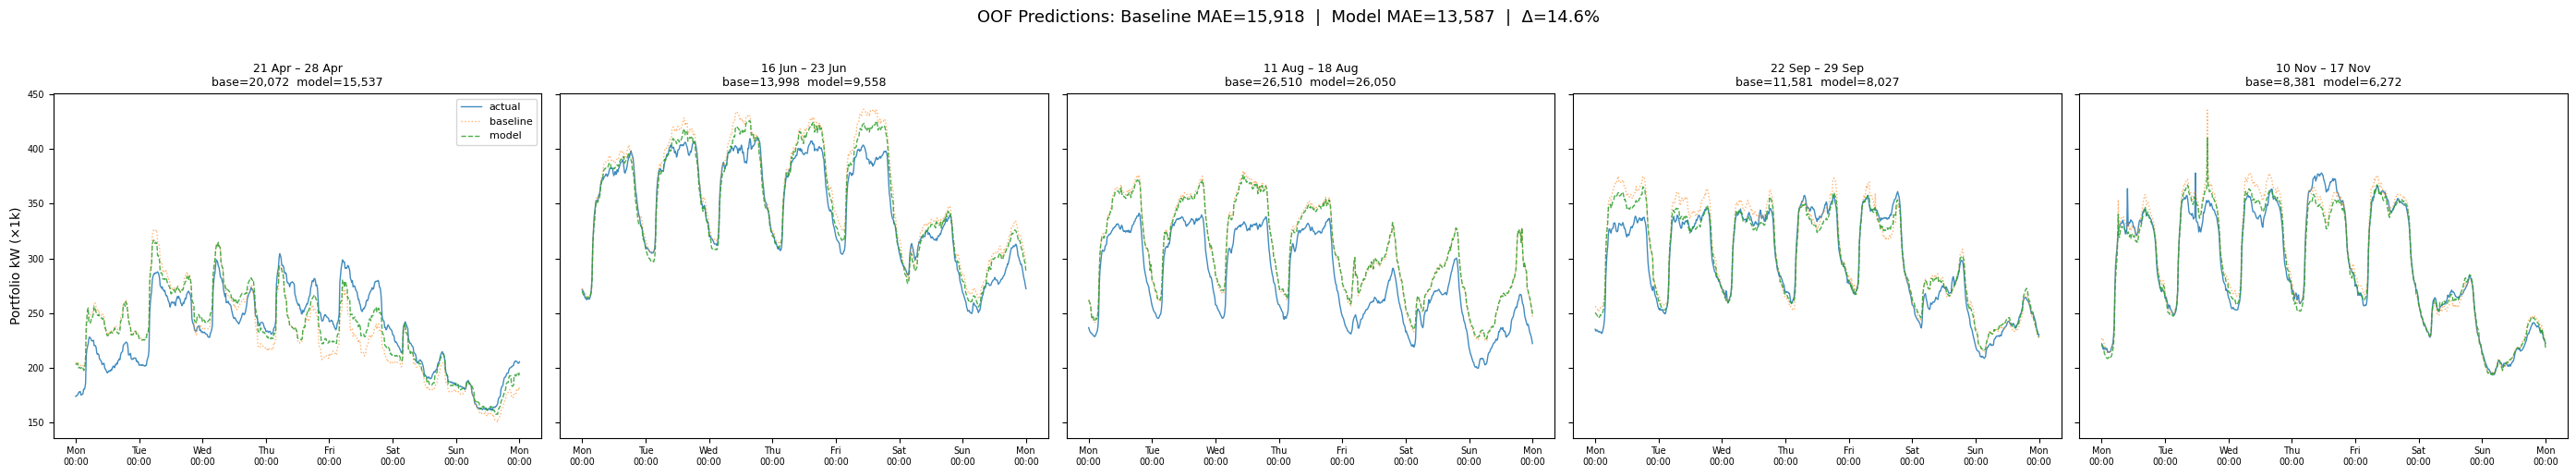

In [0]:
import matplotlib.pyplot as plt, matplotlib.dates as mdates

# ── Build final blended predictions (w=0.5) aggregated per timestep ────────
bl["p_blend"] = 0.5 * bl["p_com"] + 0.5 * bl["p_glob"]
agg = (bl.groupby("datetime_utc")
       .agg(actual=("total_kw", "sum"),
            baseline=("baseline_kw", "sum"),
            pred=("p_blend", "sum"))
       .sort_index())

mae_base  = mean_absolute_error(agg["actual"], agg["baseline"])
mae_model = mean_absolute_error(agg["actual"], agg["pred"])
print(f"Baseline MAE  = {mae_base:,.0f}")
print(f"Model MAE     = {mae_model:,.0f}")
print(f"Improvement   = {mae_base - mae_model:,.0f}  ({(1 - mae_model/mae_base)*100:.1f}%)")

# ── Sample one week from each fold's validation period ─────────────────
week_starts = [
    pd.Timestamp("2025-04-21"),
    pd.Timestamp("2025-06-16"),
    pd.Timestamp("2025-08-11"),
    pd.Timestamp("2025-09-22"),
    pd.Timestamp("2025-11-10"),
]

fig, axes = plt.subplots(1, len(week_starts), figsize=(28, 5), sharey=True)
for j, ws in enumerate(week_starts):
    we = ws + pd.Timedelta(days=7)
    c = agg.loc[ws:we]
    ax = axes[j]
    ax.plot(c.index, c["actual"]   / 1e3, lw=1, alpha=0.85, label="actual")
    ax.plot(c.index, c["baseline"] / 1e3, lw=1, alpha=0.6,  label="baseline", ls=":")
    ax.plot(c.index, c["pred"]     / 1e3, lw=1, alpha=0.85, label="model", ls="--")
    wk_mae_b = mean_absolute_error(c["actual"], c["baseline"])
    wk_mae_m = mean_absolute_error(c["actual"], c["pred"])
    ax.set_title(f"{ws.strftime('%d %b')} \u2013 {we.strftime('%d %b')}\nbase={wk_mae_b:,.0f}  model={wk_mae_m:,.0f}", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%H:%M"))
    ax.tick_params(labelsize=7)
    if j == 0:
        ax.set_ylabel("Portfolio kW (\u00d71k)", fontsize=10)
        ax.legend(fontsize=8)

fig.suptitle(f"OOF Predictions: Baseline MAE={mae_base:,.0f}  |  Model MAE={mae_model:,.0f}  |  \u0394={(1-mae_model/mae_base)*100:.1f}%",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

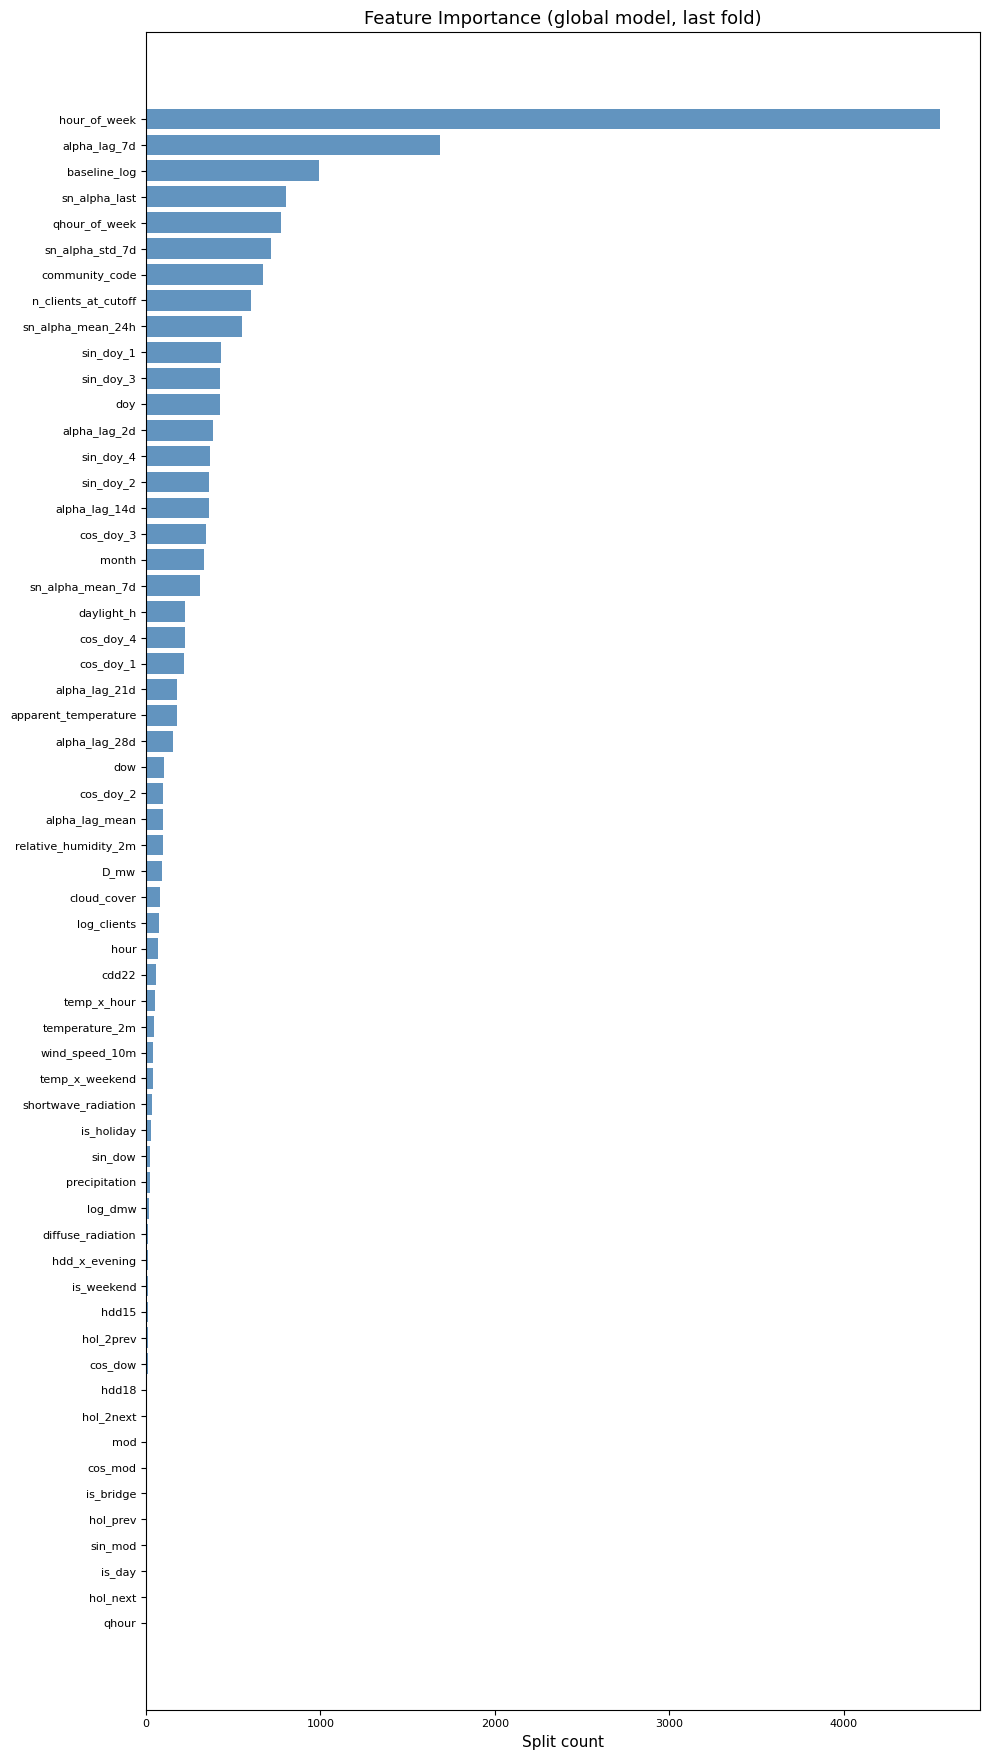

In [0]:
import matplotlib.pyplot as plt

# ── Feature importance from the last global model (cell 4) ───────────────
imp = pd.DataFrame({
    "feature": FEATS_G,
    "gain": m.feature_importances_,
}).sort_values("gain", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(imp) * 0.3)))
ax.barh(imp["feature"], imp["gain"], color="steelblue", alpha=0.85)
ax.set_xlabel("Split count", fontsize=11)
ax.set_title("Feature Importance (global model, last fold)", fontsize=13)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[11]	valid_0's l1: 0.106524
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[7]	valid_0's l1: 0.0673983
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[71]	valid_0's l1: 0.0834167
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[161]	valid_0's l1: 0.121611
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[60]	valid_0's l1: 0.053111
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[34]	valid_0's l1: 0.0604108
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[20]	valid_0's l1: 0.155888
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's l1: 0.06602

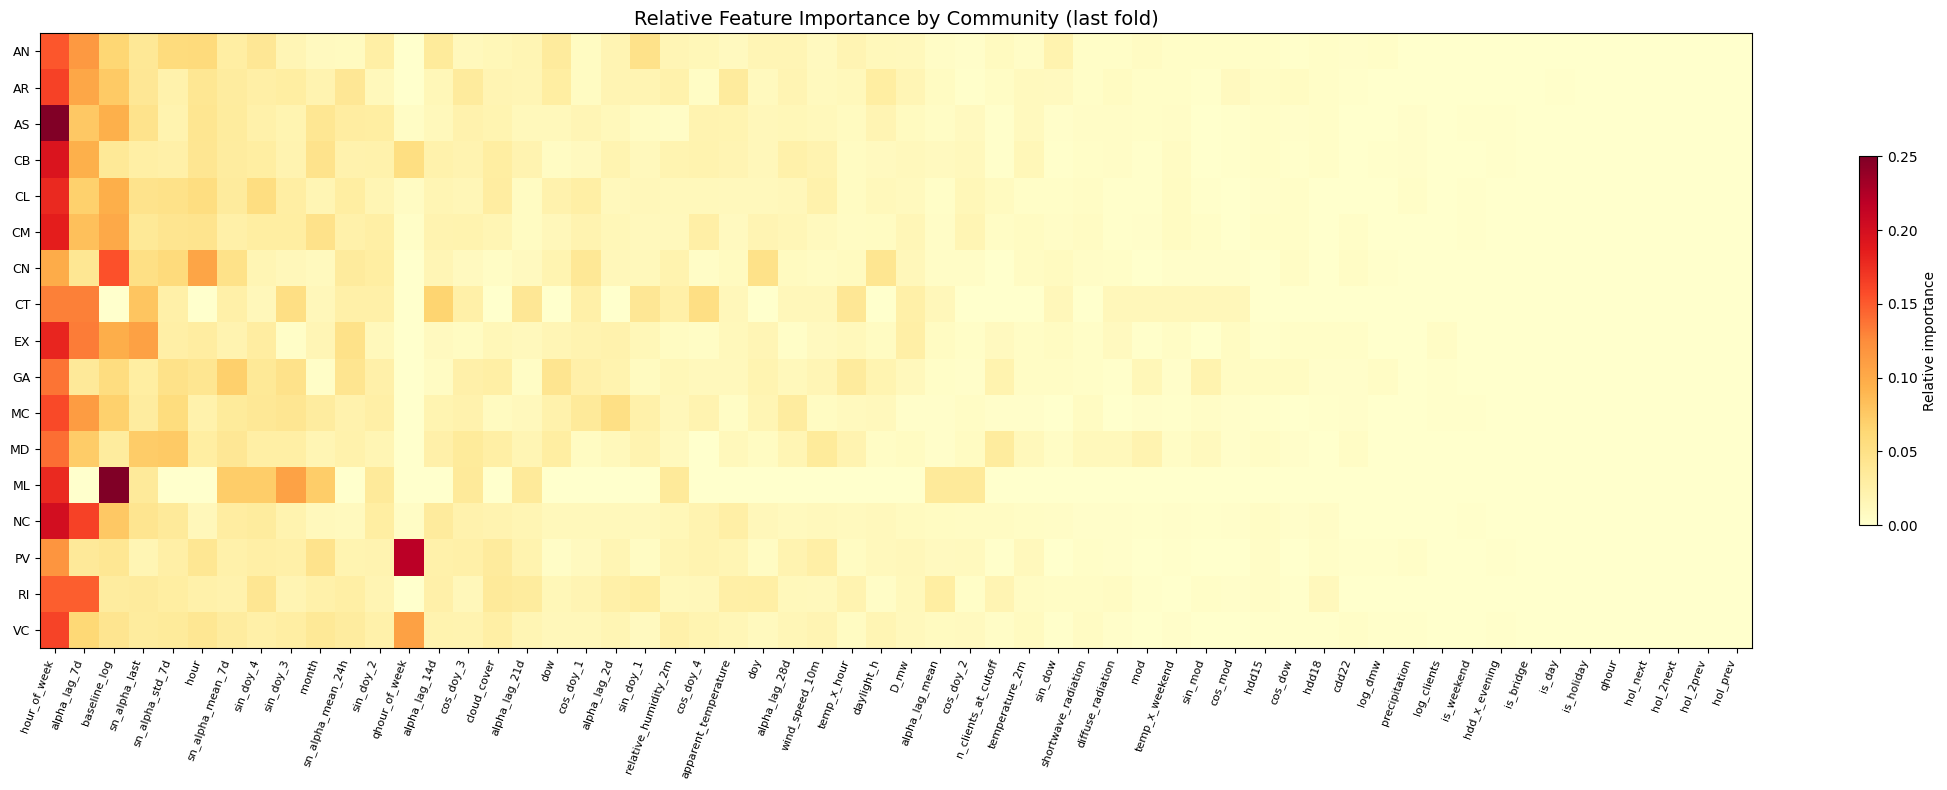


Top-5 features per community:
  AN: hour_of_week(15%), alpha_lag_7d(11%), baseline_log(6%), hour(6%), sn_alpha_std_7d(6%)
  AR: hour_of_week(16%), alpha_lag_7d(10%), baseline_log(7%), hour(4%), sn_alpha_last(4%)
  AS: hour_of_week(25%), baseline_log(10%), alpha_lag_7d(8%), sn_alpha_last(5%), hour(4%)
  CB: hour_of_week(19%), alpha_lag_7d(10%), qhour_of_week(5%), month(5%), hour(4%)
  CL: hour_of_week(18%), baseline_log(10%), alpha_lag_7d(7%), hour(5%), sin_doy_4(5%)
  CM: hour_of_week(18%), baseline_log(10%), alpha_lag_7d(8%), month(5%), hour(4%)
  CN: baseline_log(16%), hour(10%), hour_of_week(10%), sn_alpha_std_7d(6%), sn_alpha_last(5%)
  CT: hour_of_week(13%), alpha_lag_7d(13%), sn_alpha_last(8%), alpha_lag_14d(7%), sin_doy_3(5%)
  EX: hour_of_week(18%), alpha_lag_7d(13%), sn_alpha_last(11%), baseline_log(10%), sn_alpha_mean_24h(5%)
  GA: hour_of_week(14%), sn_alpha_mean_7d(7%), baseline_log(6%), sn_alpha_std_7d(5%), sin_doy_3(5%)
  MC: hour_of_week(16%), alpha_lag_7d(11%), baselin

In [0]:
import matplotlib.pyplot as plt
import numpy as np, pandas as pd

# ── Feature importance per community (last fold, most training data) ─────
train_end, val_start, val_end = folds[-1]

imp_dict = {}
for com in communities:
    sub = d[d["community_code"] == com]
    tr  = sub[sub["target_date"] < train_end]
    va  = sub[(sub["target_date"] >= val_start) & (sub["target_date"] < val_end)]
    if len(tr) < 2000 or len(va) == 0:
        continue
    mc = lgb.LGBMRegressor(**PARAMS)
    mc.fit(
        tr[FEATS], tr["y_log"],
        sample_weight=tr["baseline_kw"].values,
        eval_set=[(va[FEATS], va["y_log"])],
        eval_sample_weight=[va["baseline_kw"].values],
        categorical_feature=CATS,
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
    )
    imp_dict[com] = mc.feature_importances_

imp_df = pd.DataFrame(imp_dict, index=FEATS).T  # rows=communities, cols=features

# normalise per community (row) so we see relative importance
imp_norm = imp_df.div(imp_df.sum(axis=1), axis=0)

# sort features by mean importance
feat_order = imp_norm.mean().sort_values(ascending=False).index
imp_norm = imp_norm[feat_order]

# ── Heatmap ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, max(8, len(imp_norm) * 0.45)))
im = ax.imshow(imp_norm.values, aspect="auto", cmap="YlOrRd")

ax.set_yticks(range(len(imp_norm)))
ax.set_yticklabels(imp_norm.index, fontsize=9)
ax.set_xticks(range(len(feat_order)))
ax.set_xticklabels(feat_order, rotation=70, ha="right", fontsize=8)
ax.set_title("Relative Feature Importance by Community (last fold)", fontsize=14)
fig.colorbar(im, ax=ax, shrink=0.6, label="Relative importance")
plt.tight_layout()
plt.show()

# ── Top-5 features per community ───────────────────────────────────
print("\nTop-5 features per community:")
for com in sorted(imp_norm.index):
    top5 = imp_norm.loc[com].nlargest(5)
    feats_str = ", ".join(f"{f}({v:.0%})" for f, v in top5.items())
    print(f"  {com}: {feats_str}")

In [0]:
# Tag each OOF row with its fold
oof["fold"] = -1
for fi, (_, vs, ve) in enumerate(folds):
    mask = (oof["datetime_utc"] >= vs) & (oof["datetime_utc"] < ve)
    oof.loc[mask, "fold"] = fi

# Per-community × fold lift vs baseline
diag = (oof.groupby(["fold","community_code"])
           .apply(lambda g: pd.Series({
               "mae_base":  (g["baseline_kw"] - g["total_kw"]).abs().mean(),
               "mae_model": (g["pred_kw"]     - g["total_kw"]).abs().mean(),
               "n": len(g)}))
           .reset_index())
diag["lift_%"] = (1 - diag["mae_model"]/diag["mae_base"]) * 100

print("=== LIFT % BY (community × fold) — positive = model helps ===")
print(diag.pivot(index="community_code", columns="fold", values="lift_%").round(1))

# Overall per-community
per_com = (oof.groupby("community_code")
              .apply(lambda g: pd.Series({
                  "mae_base":  (g["baseline_kw"] - g["total_kw"]).abs().mean(),
                  "mae_model": (g["pred_kw"]     - g["total_kw"]).abs().mean()}))
              .assign(lift_pct=lambda x: (1 - x["mae_model"]/x["mae_base"])*100)
              .sort_values("lift_pct"))
print("\n=== OVERALL PER-COMMUNITY ===")
print(per_com.round(1))

# Worst days at portfolio level (where to focus feature engineering)
oof["date"] = pd.to_datetime(oof["datetime_utc"]).dt.date
daily = (oof.groupby("date")
           .agg(actual=("total_kw","sum"), pred=("pred_kw","sum"), base=("baseline_kw","sum")))
daily["err_model"] = (daily["pred"] - daily["actual"]).abs()
daily["err_base"]  = (daily["base"] - daily["actual"]).abs()
daily["lift_%"]    = (1 - daily["err_model"]/daily["err_base"]) * 100
print("\n=== 15 WORST MODEL DAYS (portfolio) ===")
print(daily.nlargest(15, "err_model")[["err_model","err_base","lift_%"]].round(0))

# Holiday vs non-holiday
hol_map = pdf.groupby("target_date")["is_holiday"].max()
oof["target_date"] = pd.to_datetime(oof["datetime_utc"]).dt.normalize()
oof["is_hol"] = oof["target_date"].map(hol_map).fillna(0).astype(int)
hol_stats = (oof.assign(e_m=(oof["pred_kw"]-oof["total_kw"]).abs(),
                        e_b=(oof["baseline_kw"]-oof["total_kw"]).abs())
               .groupby("is_hol")[["e_m","e_b"]].mean())
hol_stats["lift_%"] = (1 - hol_stats["e_m"]/hol_stats["e_b"])*100
print("\n=== MAE: HOLIDAY vs NON-HOLIDAY ===")
print(hol_stats.round(1))

=== LIFT % BY (community × fold) — positive = model helps ===
fold              -1     0     1     2     3     4
community_code                                    
AN              69.4  10.4   3.9  -1.0  16.2  11.2
AR             -36.7  -2.2   0.2   0.2  22.6   3.2
AS             -24.6   7.0  29.6  26.7  30.9  19.8
CB             -63.0  -5.1   8.1  19.2  19.0  14.6
CE               NaN   NaN   NaN   NaN   0.0   0.0
CL             -82.5  12.2  11.2  14.7   3.0  16.5
CM             -13.3   1.9  18.3  14.1   1.6  17.9
CN               0.0  -0.0 -18.0  -8.3  -0.4   4.5
CT              77.4   8.9  -0.1  18.6   3.6   7.2
EX              -1.6   0.1   0.5  23.7  18.8   0.5
GA              73.4   1.7   0.4  21.5   8.9  15.6
MC             -17.1  -0.3  20.9   0.6   1.4   6.4
MD              -7.4  -0.6  -0.4  14.6  15.4   6.8
ML               NaN   NaN  -0.0   9.8   2.4  12.4
NC             -18.3  14.8  17.5   0.9   4.9  13.4
PV               0.0   8.9   2.5   4.8   8.9  32.6
RI               6.8

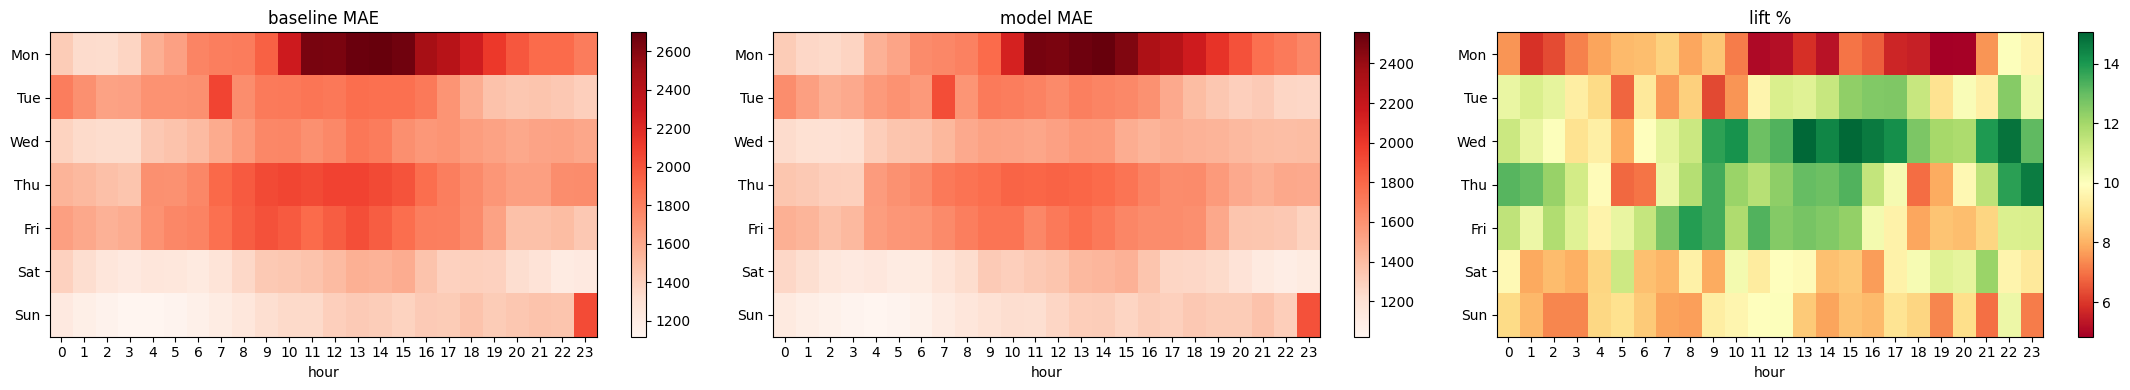


=== Worst 20 (dow,hour) cells by lift ===
dow  hour
0    19      4.840575
     20      4.912340
     11      5.043940
     12      5.183096
     14      5.242361
     18      5.520150
     17      5.659992
     13      5.846674
     1       5.881389
1    9       6.285100
0    2       6.354669
     16      6.657707
1    5       6.791104
3    5       6.821064
     18      6.875579
6    21      6.941838
0    15      7.026609
3    6       7.030273
0    10      7.138091
6    23      7.149097
dtype: float64


In [0]:
import matplotlib.pyplot as plt

o = oof.copy()
o["hour"] = pd.to_datetime(o["datetime_utc"]).dt.hour
o["dow"]  = pd.to_datetime(o["datetime_utc"]).dt.dayofweek  # 0=Mon
o["err_m"] = (o["pred_kw"] - o["total_kw"]).abs()
o["err_b"] = (o["baseline_kw"] - o["total_kw"]).abs()

mae_m = o.groupby(["dow","hour"])["err_m"].mean().unstack()
mae_b = o.groupby(["dow","hour"])["err_b"].mean().unstack()
lift  = (1 - mae_m / mae_b) * 100

fig, axes = plt.subplots(1, 3, figsize=(22, 4))
for ax, m, t, cmap in zip(axes,
                          [mae_b, mae_m, lift],
                          ["baseline MAE", "model MAE", "lift %"],
                          ["Reds","Reds","RdYlGn"]):
    im = ax.imshow(m.values, aspect="auto", cmap=cmap)
    ax.set_xticks(range(24)); ax.set_yticks(range(7))
    ax.set_yticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
    ax.set_title(t); ax.set_xlabel("hour"); fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# Hours where model hurts
bad = lift.stack().sort_values().head(20)
print("\n=== Worst 20 (dow,hour) cells by lift ===")
print(bad)

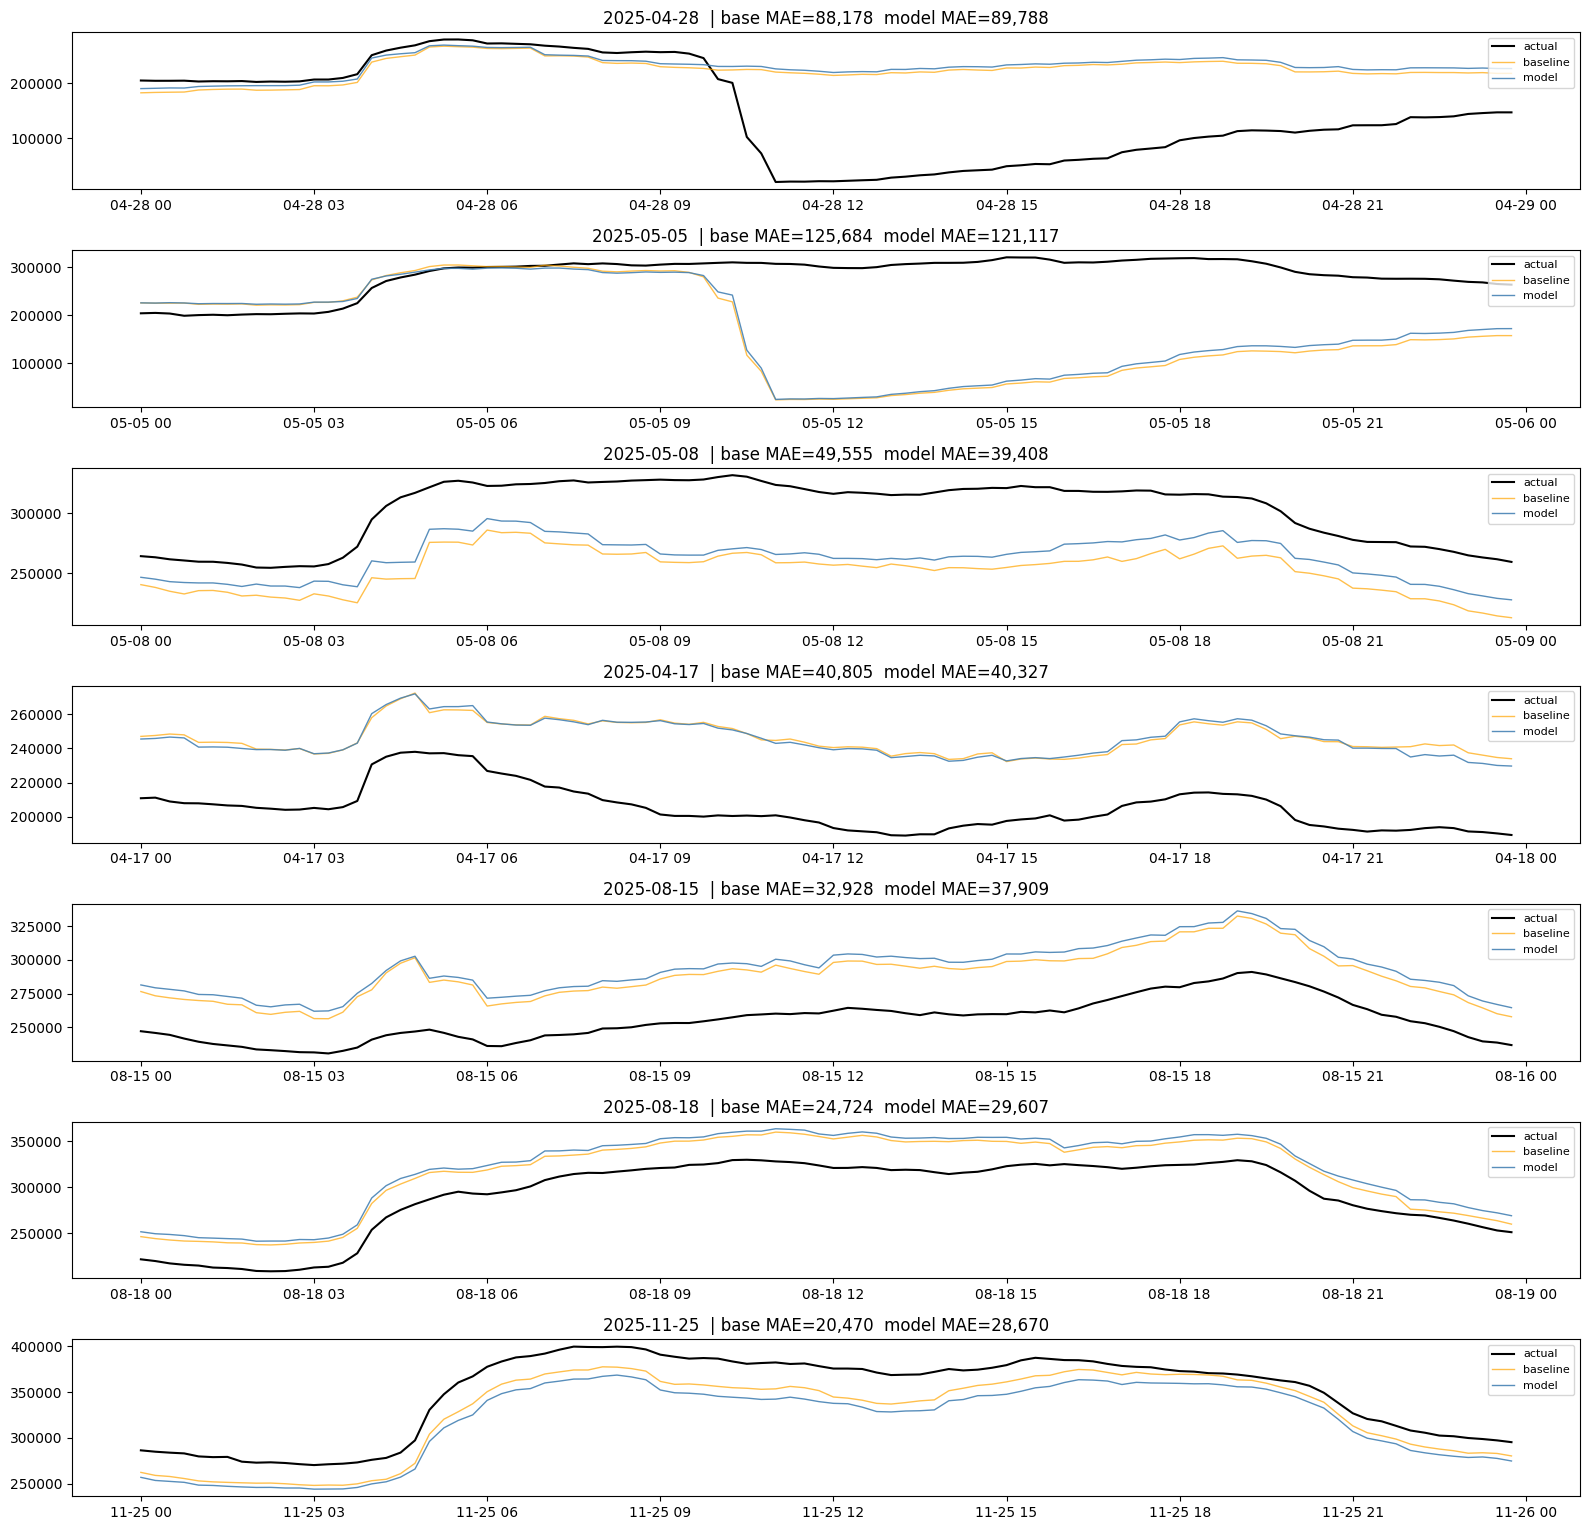

In [0]:
worst_dates = ["2025-04-28","2025-05-05","2025-05-08",
               "2025-04-17","2025-08-15","2025-08-18","2025-11-25"]

fig, axes = plt.subplots(len(worst_dates), 1, figsize=(16, 2.2*len(worst_dates)), sharex=False)
for ax, day in zip(axes, worst_dates):
    mask = pd.to_datetime(oof["datetime_utc"]).dt.date == pd.to_datetime(day).date()
    s = (oof[mask].groupby("datetime_utc")
                  .agg(a=("total_kw","sum"), p=("pred_kw","sum"), b=("baseline_kw","sum"))
                  .sort_index())
    if s.empty:
        ax.set_title(f"{day}: no data"); continue
    ax.plot(s.index, s["a"], label="actual", lw=1.5, color="black")
    ax.plot(s.index, s["b"], label="baseline", lw=1, alpha=0.7, color="orange")
    ax.plot(s.index, s["p"], label="model", lw=1, alpha=0.9, color="steelblue")
    ax.set_title(f"{day}  | base MAE={(s['b']-s['a']).abs().mean():,.0f}  model MAE={(s['p']-s['a']).abs().mean():,.0f}")
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()